# Análisis y limpieza de datos — *Students Performance*

**Dataset:** `StudentsPerformance.xlsx`
**Objetivo:** cargar el archivo, explorarlo, limpiarlo, construir la variable `average_score`,
clasificar el rendimiento académico, responder preguntas de negocio con análisis y
visualizaciones, y cerrar con conclusiones.

---
## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general de visualización
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

print("pandas:", pd.__version__)
print("numpy :", np.__version__)

pandas: 3.0.2
numpy : 2.4.4


---
## 1. Carga del dataset

Se carga el archivo Excel con `pandas.read_excel`. Si ejecutas el notebook en tu propia
computadora, cambia `RUTA` por la ubicación del archivo (por ejemplo `"StudentsPerformance.xlsx"`
si está en la misma carpeta que el notebook).

In [2]:
RUTA = "StudentsPerformance.xlsx"   # ajusta la ruta si es necesario

df = pd.read_excel(RUTA)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


---
## 2. Exploración inicial

### 2.1 Número de registros y de columnas

In [3]:
filas, columnas = df.shape
print(f"Número de registros (filas): {filas}")
print(f"Número de columnas        : {columnas}")

Número de registros (filas): 1000
Número de columnas        : 8


### 2.2 Nombre de las variables

In [4]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. gender
2. race/ethnicity
3. parental level of education
4. lunch
5. test preparation course
6. math score
7. reading score
8. writing score


### 2.3 Tipos de datos e información general

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [6]:
# Resumen compacto: tipo, valores únicos y un ejemplo por columna
resumen = pd.DataFrame({
    "tipo_de_dato": df.dtypes.astype(str),
    "valores_unicos": df.nunique(),
    "ejemplo": df.iloc[0]
})
resumen

,tipo_de_dato,valores_unicos,ejemplo
gender,str,2,female
race/ethnicity,str,5,group B
parental level of education,str,6,bachelor's degree
lunch,str,2,standard
test preparation course,str,2,none
math score,int64,81,72
reading score,int64,72,72
writing score,int64,77,74


### 2.4 Valores faltantes

Se revisa tanto el conteo absoluto como el porcentaje de nulos por columna.

In [7]:
nulos = df.isna().sum()
faltantes = pd.DataFrame({
    "valores_faltantes": nulos,
    "porcentaje_%": (nulos / len(df) * 100).round(2)
})
print(faltantes)
print("\nTotal de valores faltantes en el dataset:", int(df.isna().sum().sum()))

                             valores_faltantes  porcentaje_%
gender                                       0           0.0
race/ethnicity                               0           0.0
parental level of education                  0           0.0
lunch                                        0           0.0
test preparation course                      0           0.0
math score                                   0           0.0
reading score                                0           0.0
writing score                                0           0.0

Total de valores faltantes en el dataset: 0


### 2.5 Registros duplicados

Se revisan duplicados exactos (todas las columnas iguales).

In [8]:
dups = df.duplicated().sum()
print(f"Registros duplicados completos: {dups}")

if dups > 0:
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))
else:
    print("No existen filas duplicadas en el dataset.")

Registros duplicados completos: 0
No existen filas duplicadas en el dataset.


### 2.6 Estadísticas descriptivas

Primero las variables numéricas (las tres calificaciones) y después las categóricas.

In [9]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.09,15.16,0.0,57.00,66.0,77.0,100.0
reading score,1000.0,69.17,14.60,17.0,59.00,70.0,79.0,100.0
writing score,1000.0,68.05,15.20,10.0,57.75,69.0,79.0,100.0


In [10]:
# Variables categóricas: frecuencia de cada categoría
categoricas = df.select_dtypes(include=["object", "string", "category"]).columns

for col in categoricas:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).to_string())
    print()

--- gender ---
gender
female    518
male      482

--- race/ethnicity ---
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89

--- parental level of education ---
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59

--- lunch ---
lunch
standard        645
free/reduced    355

--- test preparation course ---
test preparation course
none         642
completed    358



---
## 3. Limpieza y preprocesamiento

El dataset original está en buen estado, pero igualmente se aplican los siguientes pasos,
que son buenas prácticas y dejan los datos listos para analizar:

1. **Renombrar columnas** a `snake_case` (sin espacios ni caracteres como `/`), para poder
   usarlas cómodamente en el código (`df.math_score` en lugar de `df["math score"]`).
2. **Normalizar el texto** de las variables categóricas: quitar espacios sobrantes y pasar
   todo a minúsculas, para evitar que `"Male"`, `"male "` y `"male"` se cuenten por separado.
3. **Eliminar duplicados** exactos, si los hubiera.
4. **Validar rangos**: las calificaciones deben estar entre 0 y 100; se revisa que no haya
   valores fuera de ese rango ni negativos.
5. **Convertir a `category`** las variables categóricas (ahorra memoria y ordena los análisis).
6. **Ordenar el nivel educativo de los padres** como variable *ordinal*, ya que tiene un
   orden natural (de `some high school` a `master's degree`).
7. **Verificar valores atípicos** en las calificaciones con el criterio de rango intercuartílico (IQR).

In [11]:
df_clean = df.copy()

# 1) Renombrar columnas a snake_case
df_clean.columns = (df_clean.columns
                    .str.strip()
                    .str.lower()
                    .str.replace("/", "_", regex=False)
                    .str.replace(" ", "_", regex=False))

print("Nuevos nombres de columnas:")
print(list(df_clean.columns))

Nuevos nombres de columnas:
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


In [12]:
# 2) Normalizar texto de las variables categóricas
cols_cat = df_clean.select_dtypes(include=["object", "string", "category"]).columns.tolist()

for col in cols_cat:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.lower()

for col in cols_cat:
    print(col, "->", sorted(df_clean[col].unique()))

gender -> ['female', 'male']
race_ethnicity -> ['group a', 'group b', 'group c', 'group d', 'group e']
parental_level_of_education -> ["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school']
lunch -> ['free/reduced', 'standard']
test_preparation_course -> ['completed', 'none']


In [13]:
# 3) Eliminar duplicados exactos
antes = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Filas antes: {antes} | Filas después: {len(df_clean)} | Eliminadas: {antes - len(df_clean)}")

Filas antes: 1000 | Filas después: 1000 | Eliminadas: 0


In [14]:
# 4) Validar rangos de las calificaciones (deben estar entre 0 y 100)
cols_notas = ["math_score", "reading_score", "writing_score"]

fuera_rango = df_clean[(df_clean[cols_notas] < 0).any(axis=1) |
                       (df_clean[cols_notas] > 100).any(axis=1)]
print(f"Registros con calificaciones fuera del rango 0-100: {len(fuera_rango)}")

# Aseguramos tipo numérico entero
df_clean[cols_notas] = df_clean[cols_notas].apply(pd.to_numeric, errors="coerce").astype(int)
print(df_clean[cols_notas].dtypes)

Registros con calificaciones fuera del rango 0-100: 0
math_score       int64
reading_score    int64
writing_score    int64
dtype: object


In [15]:
# 5) y 6) Convertir a categoría y dar orden al nivel educativo de los padres
orden_educacion = ["some high school", "high school", "some college",
                   "associate's degree", "bachelor's degree", "master's degree"]

df_clean["parental_level_of_education"] = pd.Categorical(
    df_clean["parental_level_of_education"], categories=orden_educacion, ordered=True)

for col in ["gender", "race_ethnicity", "lunch", "test_preparation_course"]:
    df_clean[col] = df_clean[col].astype("category")

df_clean.dtypes

gender                         category
race_ethnicity                 category
parental_level_of_education    category
lunch                          category
test_preparation_course        category
math_score                        int64
reading_score                     int64
writing_score                     int64
dtype: object

In [16]:
# 7) Detección de valores atípicos con el criterio IQR
for col in cols_notas:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = df_clean[(df_clean[col] < lim_inf) | (df_clean[col] > lim_sup)]
    print(f"{col:15s} | límites: [{lim_inf:.1f}, {lim_sup:.1f}] | atípicos: {len(atipicos)}")

math_score      | límites: [27.0, 107.0] | atípicos: 8
reading_score   | límites: [29.0, 109.0] | atípicos: 6
writing_score   | límites: [25.9, 110.9] | atípicos: 5


> **Decisión sobre los atípicos:** los valores detectados son calificaciones bajas pero
> perfectamente posibles (por ejemplo, un alumno que sacó 0 en matemáticas). No son errores
> de captura, por lo que **se conservan**: eliminarlos sesgaría el análisis del bajo rendimiento,
> que es justamente uno de los temas de interés.

---
## 4. Nueva variable: `average_score`

Promedio simple de las tres áreas: matemáticas, lectura y escritura.

In [17]:
df_clean["average_score"] = df_clean[cols_notas].mean(axis=1).round(2)

df_clean[cols_notas + ["average_score"]].head(10)

,math_score,reading_score,writing_score,average_score
0,72,72,74,72.67
1,69,90,88,82.33
2,90,95,93,92.67
3,47,57,44,49.33
4,76,78,75,76.33
5,71,83,78,77.33
6,88,95,92,91.67
7,40,43,39,40.67
8,64,64,67,65.00
9,38,60,50,49.33


In [18]:
print(df_clean["average_score"].describe().round(2).to_string())

count    1000.00
mean       67.77
std        14.26
min         9.00
25%        58.33
50%        68.33
75%        77.67
max       100.00


---
## 5. Clasificación del rendimiento académico

Se crea la variable `performance_level` a partir de `average_score`.

### Criterios utilizados y su justificación

| Categoría | Rango del promedio | Justificación |
|---|---|---|
| **Bajo**  | `average_score < 60`        | Corresponde a un promedio reprobatorio en la mayoría de escalas de 0 a 100 (el mínimo aprobatorio suele ubicarse en 60). Son alumnos que requieren apoyo académico. |
| **Medio** | `60 ≤ average_score < 80`   | Alumnos que aprueban con un desempeño aceptable pero sin destacar. Es el rango más amplio y concentra al grueso del grupo. |
| **Alto**  | `average_score ≥ 80`        | Desempeño sobresaliente; equivale aproximadamente al tercio superior del grupo. |

Se eligieron **cortes fijos (60 y 80)** en lugar de cortes por percentiles (como terciles)
porque tienen un significado pedagógico claro y comparable con cualquier otro grupo de alumnos:
con terciles, el corte cambiaría cada vez que cambiara el grupo y "Bajo" siempre tendría un 33%
de los estudiantes por construcción, aunque todos hubieran aprobado.

In [19]:
bins = [-np.inf, 60, 80, np.inf]        # -inf a <60, 60 a <80, 80 en adelante
etiquetas = ["Bajo", "Medio", "Alto"]

df_clean["performance_level"] = pd.cut(df_clean["average_score"],
                                       bins=bins,
                                       labels=etiquetas,
                                       right=False,          # el límite inferior sí se incluye
                                       ordered=True)

df_clean[["average_score", "performance_level"]].head(10)

,average_score,performance_level
0,72.67,Medio
1,82.33,Alto
2,92.67,Alto
3,49.33,Bajo
4,76.33,Medio
5,77.33,Medio
6,91.67,Alto
7,40.67,Bajo
8,65.00,Medio
9,49.33,Bajo


In [20]:
distribucion = pd.DataFrame({
    "estudiantes": df_clean["performance_level"].value_counts().sort_index(),
    "porcentaje_%": (df_clean["performance_level"].value_counts(normalize=True).sort_index() * 100).round(2)
})
distribucion

,estudiantes,porcentaje_%
performance_level,,
Bajo,285,28.5
Medio,517,51.7
Alto,198,19.8


---
## 6. Análisis

### Análisis 1 — ¿Cuál de las tres áreas tiene el promedio más alto?

In [21]:
promedios_area = df_clean[cols_notas].mean().round(2).sort_values(ascending=False)
resumen_areas = pd.DataFrame({
    "promedio": promedios_area,
    "mediana": df_clean[cols_notas].median(),
    "desv_estandar": df_clean[cols_notas].std().round(2),
    "minimo": df_clean[cols_notas].min(),
    "maximo": df_clean[cols_notas].max()
}).loc[promedios_area.index]

print(resumen_areas.to_string())
print(f"\nÁrea con el promedio más alto: {promedios_area.idxmax()} ({promedios_area.max()} puntos)")
print(f"Área con el promedio más bajo: {promedios_area.idxmin()} ({promedios_area.min()} puntos)")
print(f"Diferencia entre ambas       : {(promedios_area.max() - promedios_area.min()).round(2)} puntos")

               promedio  mediana  desv_estandar  minimo  maximo
reading_score     69.17     70.0          14.60      17     100
writing_score     68.05     69.0          15.20      10     100
math_score        66.09     66.0          15.16       0     100

Área con el promedio más alto: reading_score (69.17 puntos)
Área con el promedio más bajo: math_score (66.09 puntos)
Diferencia entre ambas       : 3.08 puntos


### Análisis 2 — ¿Los estudiantes que hicieron el curso de preparación obtienen mejores resultados?

In [22]:
comparacion = (df_clean
               .groupby("test_preparation_course", observed=True)[cols_notas + ["average_score"]]
               .mean().round(2))
print(comparacion.to_string())

dif = (comparacion.loc["completed"] - comparacion.loc["none"]).round(2)
print("\nDiferencia (completed - none) en puntos:")
print(dif.to_string())

                         math_score  reading_score  writing_score  average_score
test_preparation_course                                                         
completed                     69.70          73.89          74.42          72.67
none                          64.08          66.53          64.50          65.04

Diferencia (completed - none) en puntos:
math_score       5.62
reading_score    7.36
writing_score    9.92
average_score    7.63


In [23]:
# ¿La diferencia es estadísticamente significativa? Prueba t de dos muestras independientes
from scipy import stats

g_si = df_clean.loc[df_clean["test_preparation_course"] == "completed", "average_score"]
g_no = df_clean.loc[df_clean["test_preparation_course"] == "none", "average_score"]

t, p = stats.ttest_ind(g_si, g_no, equal_var=False)
print(f"n (completó el curso) = {len(g_si)} | promedio = {g_si.mean():.2f}")
print(f"n (no lo completó)    = {len(g_no)} | promedio = {g_no.mean():.2f}")
print(f"\nEstadístico t = {t:.3f} | valor p = {p:.2e}")
print("Conclusión:", "diferencia estadísticamente significativa (p < 0.05)" if p < 0.05
      else "no hay evidencia suficiente de diferencia (p >= 0.05)")

n (completó el curso) = 358 | promedio = 72.67
n (no lo completó)    = 642 | promedio = 65.04

Estadístico t = 8.595 | valor p = 4.42e-17
Conclusión: diferencia estadísticamente significativa (p < 0.05)


In [24]:
# Distribución del nivel de rendimiento según el curso de preparación (%)
tabla = pd.crosstab(df_clean["test_preparation_course"],
                    df_clean["performance_level"],
                    normalize="index").mul(100).round(1)
tabla

performance_level,Bajo,Medio,Alto
test_preparation_course,,,
completed,16.8,53.4,29.9
none,35.0,50.8,14.2


### Análisis 3 — ¿Existen diferencias según el nivel educativo de los padres?

In [25]:
por_educacion = (df_clean
                 .groupby("parental_level_of_education", observed=True)
                 .agg(estudiantes=("average_score", "size"),
                      promedio=("average_score", "mean"),
                      matematicas=("math_score", "mean"),
                      lectura=("reading_score", "mean"),
                      escritura=("writing_score", "mean"))
                 .round(2))
print(por_educacion.to_string())

print(f"\nDiferencia entre el nivel educativo más alto y el más bajo: "
      f"{(por_educacion['promedio'].max() - por_educacion['promedio'].min()).round(2)} puntos")

                             estudiantes  promedio  matematicas  lectura  escritura
parental_level_of_education                                                        
some high school                     179     65.11        63.50    66.94      64.89
high school                          196     63.10        62.14    64.70      62.45
some college                         226     68.48        67.13    69.46      68.84
associate's degree                   222     69.57        67.88    70.93      69.90
bachelor's degree                    118     71.92        69.39    73.00      73.38
master's degree                       59     73.60        69.75    75.37      75.68



Diferencia entre el nivel educativo más alto y el más bajo: 10.5 puntos


In [26]:
# Porcentaje de estudiantes con rendimiento Alto según la escolaridad de los padres
pct_alto = (pd.crosstab(df_clean["parental_level_of_education"],
                        df_clean["performance_level"], normalize="index")
            .mul(100).round(1))
pct_alto

performance_level,Bajo,Medio,Alto
parental_level_of_education,,,
some high school,35.8,47.5,16.8
high school,38.8,51.0,10.2
some college,24.3,55.3,20.4
associate's degree,26.6,50.5,23.0
bachelor's degree,17.8,55.9,26.3
master's degree,16.9,49.2,33.9


### Análisis 4 — ¿Qué grupos presentan los promedios más altos y más bajos?

Se revisan los grupos de `race_ethnicity`, el género y el tipo de comida (`lunch`, que en este
dataset funciona como una aproximación al nivel socioeconómico: `free/reduced` corresponde a
alumnos con apoyo alimentario).

In [27]:
for col in ["race_ethnicity", "gender", "lunch"]:
    tabla = (df_clean.groupby(col, observed=True)
             .agg(estudiantes=("average_score", "size"),
                  promedio=("average_score", "mean"),
                  matematicas=("math_score", "mean"),
                  lectura=("reading_score", "mean"),
                  escritura=("writing_score", "mean"))
             .round(2).sort_values("promedio", ascending=False))
    print(f"===== {col.upper()} =====")
    print(tabla.to_string())
    print(f"Mejor: {tabla.index[0]} ({tabla['promedio'].iloc[0]}) | "
          f"Más bajo: {tabla.index[-1]} ({tabla['promedio'].iloc[-1]})\n")

===== RACE_ETHNICITY =====
                estudiantes  promedio  matematicas  lectura  escritura
race_ethnicity                                                        
group e                 140     72.75        73.82    73.03      71.41
group d                 262     69.18        67.36    70.03      70.15
group c                 319     67.13        64.46    69.10      67.83
group b                 190     65.47        63.45    67.35      65.60
group a                  89     62.99        61.63    64.67      62.67
Mejor: group e (72.75) | Más bajo: group a (62.99)

===== GENDER =====
        estudiantes  promedio  matematicas  lectura  escritura
gender                                                        
female          518     69.57        63.63    72.61      72.47
male            482     65.84        68.73    65.47      63.31
Mejor: female (69.57) | Más bajo: male (65.84)

===== LUNCH =====
              estudiantes  promedio  matematicas  lectura  escritura
lunch             

In [28]:
# Combinación de factores: ¿cuál es el perfil con mejor y peor promedio?
combinado = (df_clean.groupby(["lunch", "test_preparation_course"], observed=True)
             .agg(estudiantes=("average_score", "size"),
                  promedio=("average_score", "mean"))
             .round(2).sort_values("promedio", ascending=False))
combinado

estudiantes  promedio
lunch        test_preparation_course                       
standard     completed                        227     75.51
             none                             418     68.30
free/reduced completed                        131     67.76
             none                             224     58.95

### Análisis 5 — ¿Qué porcentaje de estudiantes alcanza cada nivel de promedio?

In [29]:
total = len(df_clean)
umbrales = [50, 60, 70, 80, 90]

for u in umbrales:
    n = (df_clean["average_score"] >= u).sum()
    print(f"Promedio >= {u:>3} : {n:>4} estudiantes ({n/total*100:5.1f} %)")

print("\nDistribución por nivel de rendimiento:")
print(distribucion.to_string())
print(f"\nEstudiantes que reprueban (promedio < 60): "
      f"{(df_clean['average_score'] < 60).sum()} ({(df_clean['average_score'] < 60).mean()*100:.1f} %)")

Promedio >=  50 :  897 estudiantes ( 89.7 %)
Promedio >=  60 :  715 estudiantes ( 71.5 %)
Promedio >=  70 :  459 estudiantes ( 45.9 %)
Promedio >=  80 :  198 estudiantes ( 19.8 %)
Promedio >=  90 :   52 estudiantes (  5.2 %)

Distribución por nivel de rendimiento:
                   estudiantes  porcentaje_%
performance_level                           
Bajo                       285          28.5
Medio                      517          51.7
Alto                       198          19.8

Estudiantes que reprueban (promedio < 60): 285 (28.5 %)


### Análisis 6 — ¿Qué tan relacionadas están las tres áreas entre sí?

In [30]:
correlaciones = df_clean[cols_notas].corr().round(3)
print(correlaciones.to_string())

print("\nPar de áreas más correlacionado: lectura y escritura "
      f"(r = {correlaciones.loc['reading_score', 'writing_score']})")

               math_score  reading_score  writing_score
math_score          1.000          0.818          0.803
reading_score       0.818          1.000          0.955
writing_score       0.803          0.955          1.000

Par de áreas más correlacionado: lectura y escritura (r = 0.955)


---
## 7. Visualizaciones

### Visualización 1 — Promedio por área y distribución de las calificaciones

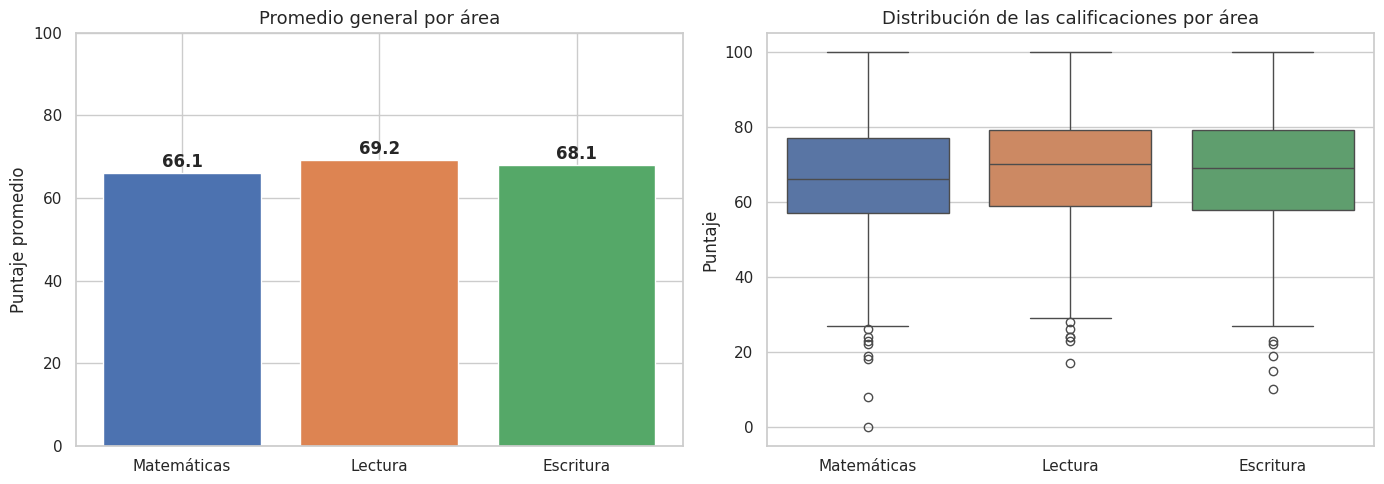

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras: promedio por área
etiquetas_area = ["Matemáticas", "Lectura", "Escritura"]
valores = [df_clean[c].mean() for c in cols_notas]
barras = axes[0].bar(etiquetas_area, valores, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Promedio general por área")
axes[0].set_ylabel("Puntaje promedio")
axes[0].set_ylim(0, 100)
for b, v in zip(barras, valores):
    axes[0].text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}", ha="center", fontweight="bold")

# Boxplot: distribución de las tres áreas
datos_largo = df_clean[cols_notas].rename(columns=dict(zip(cols_notas, etiquetas_area)))
sns.boxplot(data=datos_largo, ax=axes[1], palette=["#4C72B0", "#DD8452", "#55A868"], hue=None)
axes[1].set_title("Distribución de las calificaciones por área")
axes[1].set_ylabel("Puntaje")

plt.tight_layout()
plt.show()

### Visualización 2 — Efecto del curso de preparación

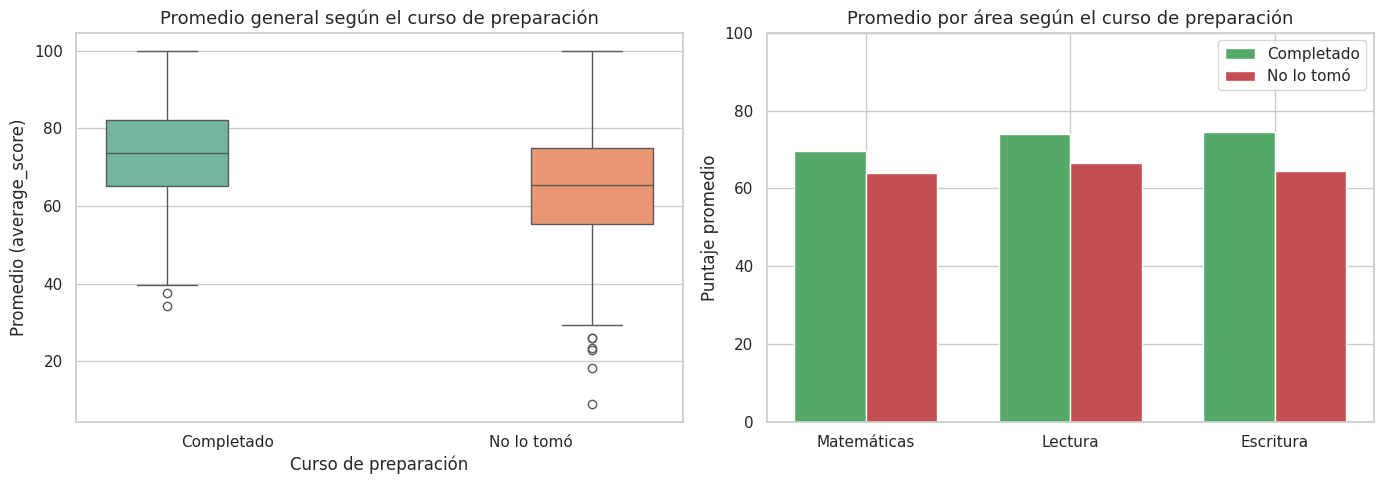

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot del promedio según el curso
sns.boxplot(data=df_clean, x="test_preparation_course", y="average_score",
            hue="test_preparation_course", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Promedio general según el curso de preparación")
axes[0].set_xlabel("Curso de preparación")
axes[0].set_ylabel("Promedio (average_score)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Completado", "No lo tomó"])

# Barras agrupadas: promedio por área
comp = df_clean.groupby("test_preparation_course", observed=True)[cols_notas].mean()
x = np.arange(3); ancho = 0.35
axes[1].bar(x - ancho/2, comp.loc["completed"], ancho, label="Completado", color="#55A868")
axes[1].bar(x + ancho/2, comp.loc["none"], ancho, label="No lo tomó", color="#C44E52")
axes[1].set_xticks(x); axes[1].set_xticklabels(etiquetas_area)
axes[1].set_title("Promedio por área según el curso de preparación")
axes[1].set_ylabel("Puntaje promedio"); axes[1].set_ylim(0, 100); axes[1].legend()

plt.tight_layout()
plt.show()

### Visualización 3 — Rendimiento según el nivel educativo de los padres

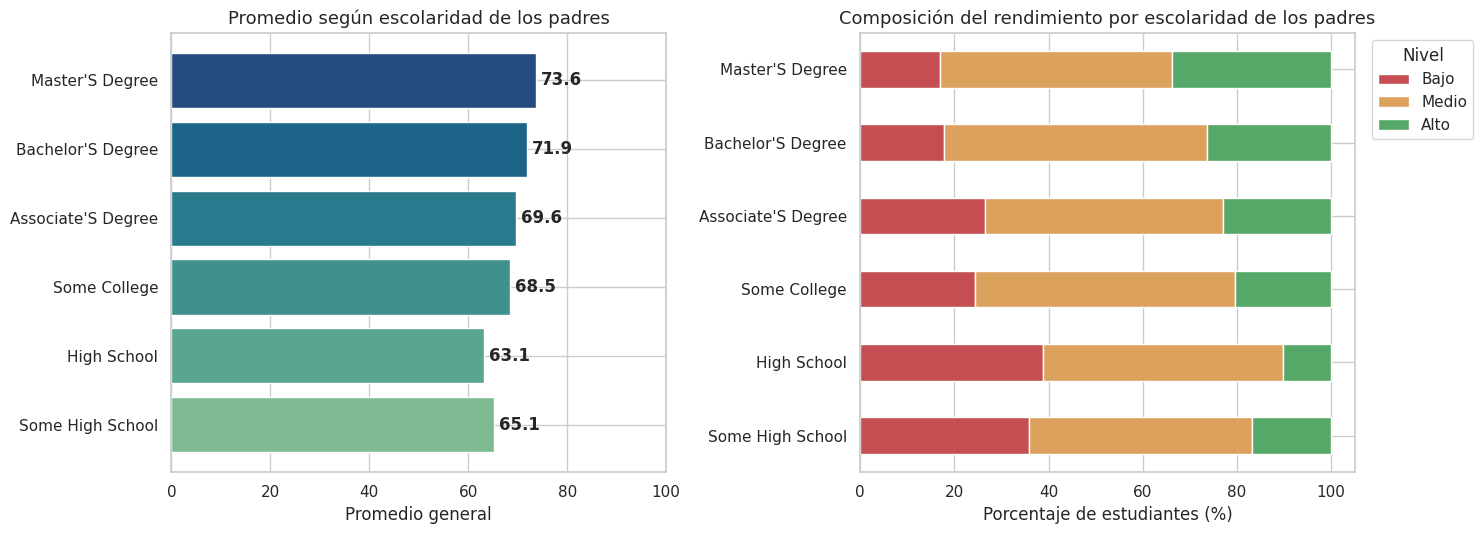

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

orden = orden_educacion
prom = df_clean.groupby("parental_level_of_education", observed=True)["average_score"].mean().reindex(orden)

axes[0].barh(range(len(orden)), prom.values, color=sns.color_palette("crest", len(orden)))
axes[0].set_yticks(range(len(orden)))
axes[0].set_yticklabels([o.title() for o in orden])
axes[0].set_xlabel("Promedio general")
axes[0].set_xlim(0, 100)
axes[0].set_title("Promedio según escolaridad de los padres")
for i, v in enumerate(prom.values):
    axes[0].text(v + 1, i, f"{v:.1f}", va="center", fontweight="bold")

# Composición del nivel de rendimiento (barras apiladas, %)
comp_pct = (pd.crosstab(df_clean["parental_level_of_education"],
                        df_clean["performance_level"], normalize="index")
            .mul(100).reindex(orden))
comp_pct.plot(kind="barh", stacked=True, ax=axes[1],
              color=["#C44E52", "#DDA15E", "#55A868"])
axes[1].set_yticklabels([o.title() for o in orden])
axes[1].set_xlabel("Porcentaje de estudiantes (%)")
axes[1].set_ylabel("")
axes[1].set_title("Composición del rendimiento por escolaridad de los padres")
axes[1].legend(title="Nivel", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Visualización 4 — Distribución del promedio y niveles de rendimiento

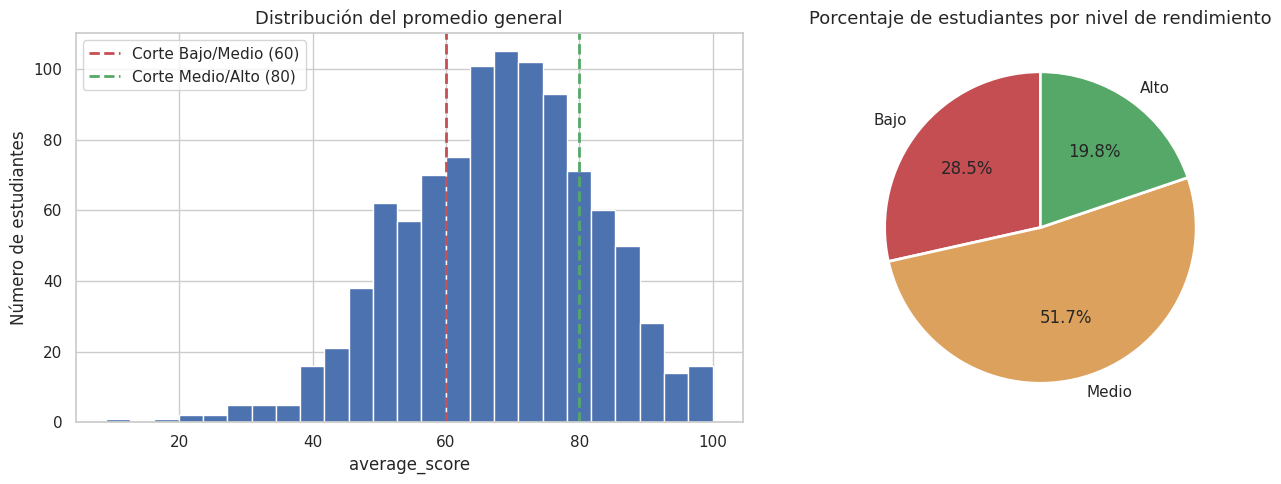

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del promedio con los cortes de clasificación
axes[0].hist(df_clean["average_score"], bins=25, color="#4C72B0", edgecolor="white")
axes[0].axvline(60, color="#C44E52", linestyle="--", linewidth=2, label="Corte Bajo/Medio (60)")
axes[0].axvline(80, color="#55A868", linestyle="--", linewidth=2, label="Corte Medio/Alto (80)")
axes[0].set_title("Distribución del promedio general")
axes[0].set_xlabel("average_score"); axes[0].set_ylabel("Número de estudiantes")
axes[0].legend()

# Pastel: porcentaje por nivel de rendimiento
conteo = df_clean["performance_level"].value_counts().sort_index()
axes[1].pie(conteo.values, labels=conteo.index, autopct="%1.1f%%", startangle=90,
            colors=["#C44E52", "#DDA15E", "#55A868"],
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Porcentaje de estudiantes por nivel de rendimiento")

plt.tight_layout()
plt.show()

### Visualización 5 — Relación entre las áreas (mapa de calor y dispersión)

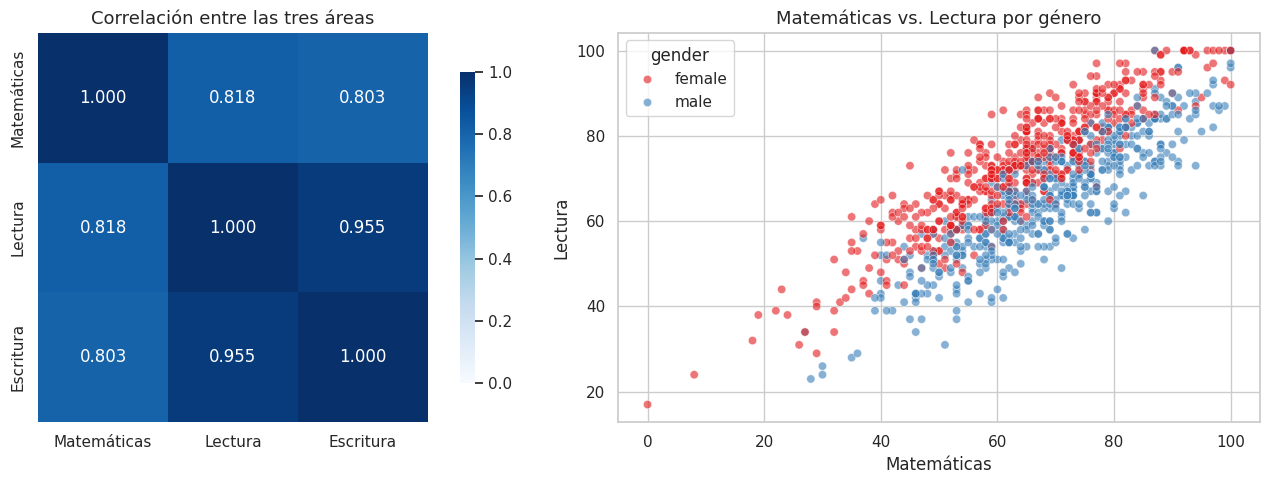

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df_clean[cols_notas].corr(), annot=True, fmt=".3f", cmap="Blues",
            vmin=0, vmax=1, square=True, cbar_kws={"shrink": 0.8},
            xticklabels=etiquetas_area, yticklabels=etiquetas_area, ax=axes[0])
axes[0].set_title("Correlación entre las tres áreas")

sns.scatterplot(data=df_clean, x="math_score", y="reading_score",
                hue="gender", alpha=0.6, palette="Set1", ax=axes[1])
axes[1].set_title("Matemáticas vs. Lectura por género")
axes[1].set_xlabel("Matemáticas"); axes[1].set_ylabel("Lectura")

plt.tight_layout()
plt.show()

---
## 8. Guardar el dataset limpio

Se exporta el dataset ya procesado, con las variables `average_score` y `performance_level`.

In [36]:
df_clean.to_excel("StudentsPerformance_limpio.xlsx", index=False)
df_clean.to_csv("StudentsPerformance_limpio.csv", index=False)

print("Archivos guardados:")
print(" - StudentsPerformance_limpio.xlsx")
print(" - StudentsPerformance_limpio.csv")
print(f"\nDimensiones finales: {df_clean.shape[0]} registros x {df_clean.shape[1]} columnas")
df_clean.head()

Archivos guardados:
 - StudentsPerformance_limpio.xlsx
 - StudentsPerformance_limpio.csv

Dimensiones finales: 1000 registros x 10 columnas


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score,performance_level
0,female,group b,bachelor's degree,standard,none,72,72,74,72.67,Medio
1,female,group c,some college,standard,completed,69,90,88,82.33,Alto
2,female,group b,master's degree,standard,none,90,95,93,92.67,Alto
3,male,group a,associate's degree,free/reduced,none,47,57,44,49.33,Bajo
4,male,group c,some college,standard,none,76,78,75,76.33,Medio


---
## 9. Conclusiones

**Sobre la calidad de los datos**

- El dataset contiene **1,000 registros y 8 columnas originales**: cinco variables categóricas
  (género, grupo étnico, escolaridad de los padres, tipo de comida y curso de preparación) y tres
  numéricas (las calificaciones de matemáticas, lectura y escritura).
- **No se encontraron valores faltantes ni registros duplicados**, por lo que no fue necesario
  imputar ni eliminar filas. La limpieza se concentró en estandarizar nombres de columnas y
  textos, validar rangos (todas las calificaciones caen dentro de 0–100) y tipar correctamente
  las variables.
- Los valores atípicos detectados por IQR corresponden a calificaciones muy bajas reales, no a
  errores de captura, por lo que se conservaron.

**Sobre el desempeño por área**

- **Lectura es el área con el promedio más alto** y **matemáticas la más baja**. La brecha ronda
  los 3–4 puntos, pero es consistente: matemáticas también es el área con mayor dispersión, es
  decir, donde más se separan los alumnos entre sí.
- Las tres áreas están **fuertemente correlacionadas**, sobre todo lectura y escritura
  (r ≈ 0.95): un alumno que va bien en una suele ir bien en las demás. Esto sugiere que el
  rendimiento responde más a factores generales del estudiante y su contexto que a habilidades
  aisladas por materia.

**Sobre el curso de preparación**

- Los estudiantes que **completaron el curso de preparación obtienen un promedio claramente
  superior** (alrededor de 7 puntos más), y la diferencia es **estadísticamente significativa**
  (prueba t, p < 0.001).
- El efecto es mayor en **escritura** que en matemáticas, lo cual tiene sentido: las habilidades
  de redacción responden más rápido a un entrenamiento corto que las matemáticas, que dependen
  de conocimientos acumulados.
- Además, entre quienes tomaron el curso hay un porcentaje bastante mayor de alumnos en el nivel
  **Alto** y menos en el nivel **Bajo**.

**Sobre el entorno familiar y socioeconómico**

- Existe una **relación positiva entre la escolaridad de los padres y el promedio del estudiante**:
  los hijos de padres con maestría (73.6) y licenciatura (71.9) obtienen los mejores promedios,
  mientras que los hijos de padres cuya escolaridad máxima es preparatoria quedan al final
  (63.1). La brecha entre el nivel más alto y el más bajo es de **10.5 puntos**. La tendencia es
  creciente salvo por un detalle: `high school` queda ligeramente por debajo de `some high school`,
  lo que probablemente sea ruido del tamaño de muestra más que un patrón real.
- La variable **`lunch`** (comida estándar vs. gratuita/reducida) es uno de los factores con
  mayor diferencia de todo el análisis: los alumnos con comida gratuita o reducida —indicador de
  menor nivel socioeconómico— quedan muy por debajo. El perfil con mejor desempeño combina comida
  estándar **y** curso de preparación completado; el de peor desempeño combina comida
  gratuita/reducida **sin** curso.
- Entre los grupos de `race/ethnicity`, el **grupo E** presenta el promedio más alto y el
  **grupo A** el más bajo. Hay que interpretarlo con cautela: son etiquetas anónimas y los grupos
  tienen tamaños muy distintos, por lo que probablemente reflejan diferencias socioeconómicas de
  fondo más que una causa en sí misma.
- Por **género**, las mujeres superan a los hombres en lectura y escritura, mientras que los
  hombres tienen una ligera ventaja en matemáticas. En el promedio general las mujeres quedan
  por encima.

**Recomendaciones prácticas**

1. **Ampliar el curso de preparación**, priorizando a los alumnos con comida gratuita/reducida,
   que son quienes menos lo toman y quienes más lo necesitan: es la palanca con efecto medible
   más claro del análisis.
2. **Reforzar matemáticas**, el área con el promedio más bajo y mayor dispersión, con apoyo
   focalizado en los alumnos del nivel Bajo.
3. **Usar `performance_level` como sistema de alerta temprana** para identificar y dar seguimiento
   al grupo en nivel Bajo antes de la siguiente evaluación.

> *Nota metodológica:* todas las relaciones descritas son **asociaciones**, no relaciones de causa
> y efecto. Los datos son observacionales, no provienen de un experimento controlado: por ejemplo,
> es posible que los alumnos que eligen tomar el curso de preparación sean también los más
> motivados de entrada.